It is unsupervised learning algorithm which comes under clustering technique and it groups the similar pattern by using euclidean distance formula

* Groups k clusters -> k is selected using elbo method.

* Step 1 : Before clustering it selects k centroids randomly.

* Step 2 : Finds the euclidean distance between the centroids(c1,c2) and each sample. group the sample based on the nearest sample(small distance).

* Step 3 : After the first iteration, new centroid for c1, c2 are formed using the mean of the c1 , c2 respectively

* Step 4 : Repeat the step 2 with new centroid un-till we get same cluster groups as last iteration.

In [184]:
# from sklearn.cluster import KMeans

# cluster = KMeans(n_clusters=2)
# cluster.fit_predict(df) # 0 1

In [185]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [186]:
df = pd.read_csv('Mall_Customers.csv')

In [187]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [188]:
df = df.drop('CustomerID',axis=1)

In [189]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


<Axes: >

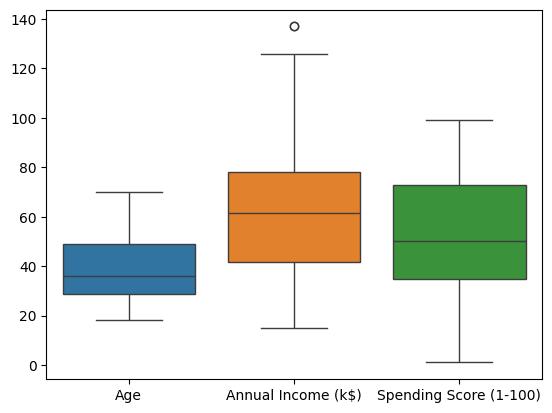

In [190]:
sns.boxplot(data=df)

In [191]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [192]:
from sklearn.cluster import KMeans

In [193]:
KM = KMeans()

In [194]:
num_col = df.select_dtypes(exclude=object).columns

In [195]:
pre = ColumnTransformer(
    transformers=[
        ("encode",OneHotEncoder(handle_unknown='ignore'),['Gender']),
        # ("Scale",StandardScaler(),['Age','Annual Income (k$)','Spending Score (1-100)'])
        ("Scale",StandardScaler(),num_col)
    ]
)

In [196]:
main_pipeline = Pipeline(
    steps=[
        ("preprocess",pre),
        ("model",KMeans(n_clusters=2,random_state=42))
    ]
)

In [197]:
main_pipeline.fit(df)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender']),
                                                 ('Scale', StandardScaler(),
                                                  Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], dtype='object'))])),
                ('model', KMeans(n_clusters=2, random_state=42))])

In [198]:
main_pipeline.fit_transform(df)

array([[2.86488709, 2.35830225],
       [3.33722993, 2.05138957],
       [2.9330497 , 3.10587326],
       [3.12329544, 1.86508728],
       [2.21389811, 2.10846981],
       [3.12464043, 1.84084952],
       [2.25150301, 3.04289121],
       [3.4976404 , 2.01317765],
       [2.35875699, 4.04821144],
       [2.6718158 , 1.69983699],
       [2.30146402, 3.93939233],
       [3.26217932, 2.10205188],
       [1.92647184, 3.42318597],
       [2.99996835, 1.71220029],
       [2.05487564, 2.87438686],
       [3.15308997, 1.85603218],
       [1.92081757, 2.15204882],
       [2.96933099, 1.83176244],
       [1.63979636, 2.84305208],
       [3.15936676, 1.96692977],
       [1.86904534, 2.15604469],
       [2.81447455, 1.65038861],
       [1.84986343, 3.16685598],
       [2.55641743, 1.61127556],
       [1.61686504, 3.14496424],
       [2.80236685, 1.57662382],
       [1.42981922, 2.32751914],
       [2.08104375, 1.60415051],
       [1.50797774, 2.17014368],
       [3.13325536, 1.55439776],
       [1.

In [199]:
df['result'] = main_pipeline.predict(df)

In [200]:
df

,Gender,Age,Annual Income (k$),Spending Score (1-100),result
0,Male,19,15,39,1
1,Male,21,15,81,1
2,Female,20,16,6,0
3,Female,23,16,77,1
4,Female,31,17,40,1
...,...,...,...,...,...
195,Female,35,120,79,1
196,Female,45,126,28,0
197,Male,32,126,74,1
198,Male,32,137,18,0


In [201]:
df_cluster_0 = df[df['result']==0]

In [202]:
df_cluster_1 = df[df['result']==1]

### Elbow Method

In [203]:
metric_ = []
for cluster in range(1,11):
    main_pipeline = Pipeline(
    steps=[
        ("preprocess",pre),
        ("model",KMeans(n_clusters=cluster,random_state=42))
    ])
    main_pipeline.fit(df)
    #print(main_pipeline.named_steps['model'].inertia_)
    
    metric_.append(main_pipeline.named_steps['model'].inertia_)
print(metric_)

[698.56, 487.6586341571177, 394.2720694203257, 303.34066704491033, 286.64524385759944, 252.17444034241123, 220.1211152932492, 187.78899002798676, 176.11390538071277, 165.48420124477335]


In [204]:
import seaborn as sns

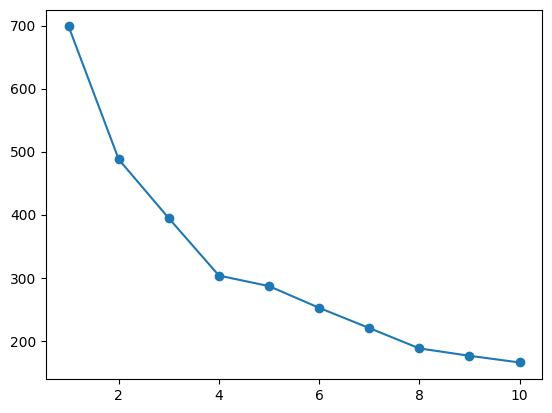

In [205]:
plt.plot(range(1,11),metric_,marker = "o")

The  curve is bending at cluster = 4, and it will be taken as best number of clusters.

In [211]:
main_pipeline = Pipeline(
    steps=[
        
        ("model",KMeans(n_clusters=4,random_state=42))
    ]
)

In [212]:
updated_df = pre.fit_transform(df)

In [213]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
pca_val = pca_2d.fit_transform(updated_df)
pca_val

array([[-0.57572361, -1.68487363],
       [-1.62359494, -1.72648138],
       [ 0.27961435, -1.72531425],
       [-1.51106396, -1.79620462],
       [-0.09546842, -1.7073466 ],
       [-1.53580344, -1.75857647],
       [ 1.03564413, -1.62747944],
       [-1.97915918, -1.73817968],
       [ 2.68028034, -1.42925712],
       [-1.02454893, -1.66667214],
       [ 2.53113695, -1.43655689],
       [-1.51023184, -1.68802373],
       [ 1.95025617, -1.52756054],
       [-1.46644971, -1.64266722],
       [ 1.03895218, -1.44106096],
       [-1.52575968, -1.53280315],
       [ 0.2377451 , -1.54415148],
       [-1.27279373, -1.48390972],
       [ 1.35574248, -1.3221625 ],
       [-1.48886023, -1.53487932],
       [ 0.32986561, -1.31519863],
       [-1.2157888 , -1.37000103],
       [ 1.60914245, -1.34429042],
       [-0.91367626, -1.32326287],
       [ 1.76323423, -1.22814291],
       [-1.2656001 , -1.22164371],
       [ 0.81535969, -1.26029561],
       [-0.3874535 , -1.19066999],
       [ 0.58821397,

In [214]:
main_pipeline.fit(pca_val)

Pipeline(steps=[('model', KMeans(n_clusters=4, random_state=42))])

In [217]:
labels = main_pipeline.predict(pca_val)

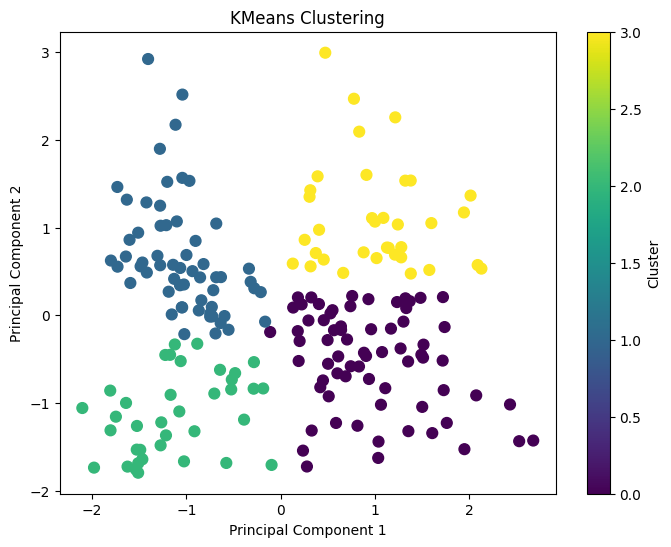

In [218]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_val[:, 0],      # Principal Component 1
    pca_val[:, 1],      # Principal Component 2
    c=labels,           # Cluster labels
    cmap="viridis",
    s=60
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("KMeans Clustering")
plt.colorbar(label="Cluster")
plt.show()

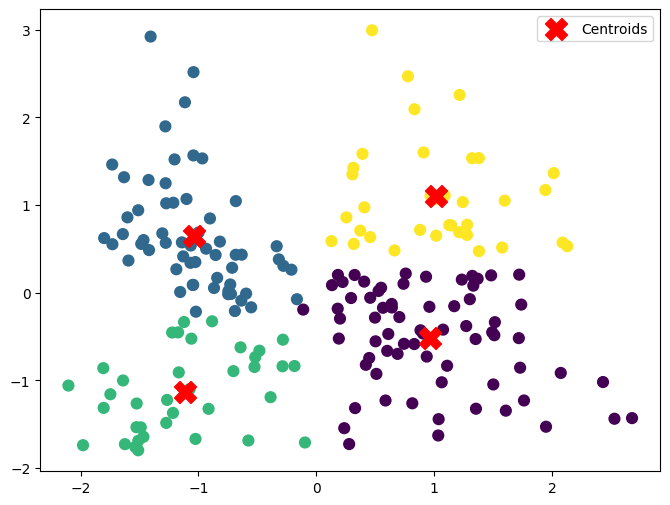

In [220]:
centers = main_pipeline.named_steps["model"].cluster_centers_

plt.figure(figsize=(8,6))

plt.scatter(
    pca_val[:,0],
    pca_val[:,1],
    c=labels,
    cmap="viridis",
    s=60
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    marker="X",
    s=250,
    color="red",
    label="Centroids"
)

plt.legend()
plt.show()